In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [ ]:
# ==========================================================
# STEP 4: LOAD DATASETS
#
# Purpose:
#   Load all CSV files into Pandas DataFrames.
#   These datasets will be used throughout the analysis.
#
# Datasets:
#   - Inventory
#   - Sales
#   - Products
#   - Suppliers
#   - Warehouses
#   - Purchase Orders
# ==========================================================

inventory = pd.read_csv("../data/inventory.csv")
sales = pd.read_csv("../data/sales.csv")
products = pd.read_csv("../data/products.csv")
suppliers = pd.read_csv("../data/suppliers.csv")
warehouses = pd.read_csv("../data/warehouses.csv")
purchase = pd.read_csv("../data/purchase_orders.csv")

In [45]:
# ==========================================================
# STEP 5: INITIAL DATA INSPECTION
#
# Purpose:
#   Gain an initial understanding of the dataset before
#   performing any cleaning or analysis.
#
# We will examine:
#   - First few records
#   - Dataset structure
#   - Summary statistics
#   - Number of rows & columns
#   - Column names
# ==========================================================
purchase.head()


,PO_ID,Supplier_ID,SKU,Order_Qty,Received_Qty,Lead_Time,Delay_Days
0,PO000001,SUP029,SKU0663,481,464,3,6
1,PO000002,SUP024,SKU0795,442,422,12,3
2,PO000003,SUP006,SKU0723,471,462,10,0
3,PO000004,SUP009,SKU0347,194,188,6,4
4,PO000005,SUP002,SKU0181,113,100,14,1


In [21]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PO_ID         12000 non-null  object
 1   Supplier_ID   12000 non-null  object
 2   SKU           12000 non-null  object
 3   Order_Qty     12000 non-null  int64 
 4   Received_Qty  12000 non-null  int64 
 5   Lead_Time     12000 non-null  int64 
 6   Delay_Days    12000 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 656.4+ KB


In [22]:
purchase.describe()

,Order_Qty,Received_Qty,Lead_Time,Delay_Days
count,12000.000000,12000.000000,12000.000000,12000.000000
mean,259.490083,249.458083,7.979167,3.985083
std,138.590006,138.753532,3.758889,2.568413
min,20.000000,1.000000,2.000000,0.000000
25%,141.000000,131.000000,5.000000,2.000000
50%,260.000000,250.000000,8.000000,4.000000
75%,379.000000,369.000000,11.000000,6.000000
max,500.000000,499.000000,14.000000,8.000000


In [23]:
purchase.shape

(12000, 7)

In [24]:
purchase.columns

Index(['PO_ID', 'Supplier_ID', 'SKU', 'Order_Qty', 'Received_Qty', 'Lead_Time',
       'Delay_Days'],
      dtype='object')

# Business Problem

RetailMart Malaysia is experiencing increasing inventory costs while frequent stock-out issues continue to occur.

Management has requested an inventory analysis to identify operational inefficiencies and improve inventory management.

## Objectives

- Identify products that require immediate replenishment.
- Detect overstocked and slow-moving inventory.
- Evaluate warehouse inventory distribution.
- Assess supplier performance.
- Provide actionable business recommendations to improve inventory efficiency.

In [ ]:
# ==========================================================
# STEP 7: DATA QUALITY ASSESSMENT
#
# Purpose:
#   Evaluate the overall quality of the dataset before
#   performing any data cleaning.
#
# We will check:
#   - Missing values
#   - Duplicate records
#   - Data types
#   - Number of unique values
# ==========================================================

# Count missing values in each column
purchase.isnull().sum()
# Count duplicate rows
inventory.duplicated().sum()
# Display the data type of each column
inventory.dtypes
# Count unique values in each column
inventory.nunique()

PO_ID           0
Supplier_ID     0
SKU             0
Order_Qty       0
Received_Qty    0
Lead_Time       0
Delay_Days      0
dtype: int64

In [40]:
# ==========================================================
# STEP 8: CHECK DATASET SIZE & DUPLICATE RECORDS
# Purpose:
#   Understand the size of each dataset and identify
#   duplicate records before starting data cleaning.
# ==========================================================

# Store all datasets inside a dictionary
# Key = dataset name
# Value = dataframe
datasets = {
    "Inventory": inventory,
    "Sales": sales,
    "Products": products,
    "Suppliers": suppliers,
    "Warehouses": warehouses,
    "Purchase Orders": purchase
}

# Loop through every dataframe
for name, df in datasets.items():

    print(f"\n{name}")

    # Display number of rows and columns
    print("Dataset Shape:", df.shape)

    # Count duplicate rows
    print("Duplicate Records:", df.duplicated().sum())

    print("-" * 40)


Inventory
Dataset Shape: (10050, 8)
Duplicate Records: 50
----------------------------------------

Sales
Dataset Shape: (25000, 7)
Duplicate Records: 0
----------------------------------------

Products
Dataset Shape: (1000, 6)
Duplicate Records: 0
----------------------------------------

Suppliers
Dataset Shape: (30, 4)
Duplicate Records: 0
----------------------------------------

Warehouses
Dataset Shape: (8, 2)
Duplicate Records: 0
----------------------------------------

Purchase Orders
Dataset Shape: (12000, 7)
Duplicate Records: 0
----------------------------------------


In [55]:
# ==========================================================
# STEP 9: REMOVE DUPLICATE RECORDS
# Purpose:
#   Create a clean version of the inventory dataset
#   by removing duplicated rows.
# ==========================================================

# Remove duplicate rows
inventory_clean = inventory.drop_duplicates().copy()

# Display dataset size after cleaning
inventory_clean.shape

# Direct way to change original dataset
# inventory.drop_duplicates(inplace=True)

(10000, 8)

In [52]:
# ==========================================================
# STEP 10: CHECK MISSING VALUES IN INVENTORY DATA
#
# Purpose:
#   Identify columns with missing values before deciding
#   the appropriate cleaning strategy.
#
# Expected Output:
#   Number of missing values for each column.
# ==========================================================

inventory_clean.isnull().sum()

Date              0
Warehouse         0
SKU               0
Current_Stock    13
Reorder_Level     0
Max_Stock         0
Damaged_Qty       0
Holding_Cost      0
dtype: int64

In [56]:
# ==========================================================
# STEP 11: HANDLE MISSING VALUES IN CURRENT STOCK
#
# Purpose:
#   Replace missing Current_Stock values with 0 because
#   missing stock quantity may indicate no recorded stock.
#
# Note:
#   This decision is made for portfolio analysis purposes.
#   In a real company, we would confirm this with the
#   inventory or warehouse team first.
# ==========================================================

inventory_clean["Current_Stock"] = inventory_clean["Current_Stock"].fillna(0)

In [57]:
# ==========================================================
# STEP 12: VERIFY MISSING VALUES AFTER CLEANING
#
# Purpose:
#   Confirm that missing values in inventory data
#   have been handled successfully.
# ==========================================================

inventory_clean.isnull().sum()

Date             0
Warehouse        0
SKU              0
Current_Stock    0
Reorder_Level    0
Max_Stock        0
Damaged_Qty      0
Holding_Cost     0
dtype: int64

In [59]:
# ==========================================================
# STEP 13: DATA VALIDATION
#
# Purpose:
#   Validate the inventory dataset by checking for
#   impossible or suspicious values.
#
# Why?
#   Data validation helps ensure that our analysis is
#   based on reliable and accurate data.
# ==========================================================

# ==========================================================
# CHECK 1: Negative Current Stock
#
# Current stock should never be negative.
# ==========================================================

negative_stock = inventory_clean[inventory_clean["Current_Stock"] < 0]

print("Number of negative stock records:", len(negative_stock))

negative_stock.head()

Number of negative stock records: 0


,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost


In [60]:
# ==========================================================
# CHECK 2: Reorder Level Validation
#
# Reorder level should always be smaller than
# the maximum stock level.
# ==========================================================

invalid_reorder = inventory_clean[
    inventory_clean["Reorder_Level"] > inventory_clean["Max_Stock"]
]

print("Invalid reorder records:", len(invalid_reorder))

invalid_reorder.head()

Invalid reorder records: 0


,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost


In [61]:
# ==========================================================
# CHECK 3: Negative Holding Cost
#
# Holding cost should never be negative.
# ==========================================================

negative_cost = inventory_clean[
    inventory_clean["Holding_Cost"] < 0
]

print("Negative holding cost records:", len(negative_cost))

negative_cost.head()

Negative holding cost records: 0


,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost


In [62]:
# ==========================================================
# STEP 14: SUMMARY STATISTICS
#
# Purpose:
#   Generate descriptive statistics to understand the
#   overall distribution of numerical variables.
#
# Why?
#   This provides a quick overview of the inventory data
#   before deeper analysis.
#
# Expected Output:
#   Count, Mean, Std, Min, Max, and Quartiles.
# ==========================================================

inventory_clean.describe()

,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,400.418500,60.089000,358.734200,5.011500,48.124332
std,231.556287,23.290975,119.259754,3.169664,27.757166
min,0.000000,20.000000,120.000000,0.000000,0.000000
25%,200.000000,40.000000,258.000000,2.000000,24.120000
50%,401.000000,60.000000,357.000000,5.000000,48.120000
75%,604.000000,80.000000,461.000000,8.000000,72.480000
max,800.000000,100.000000,600.000000,10.000000,96.000000


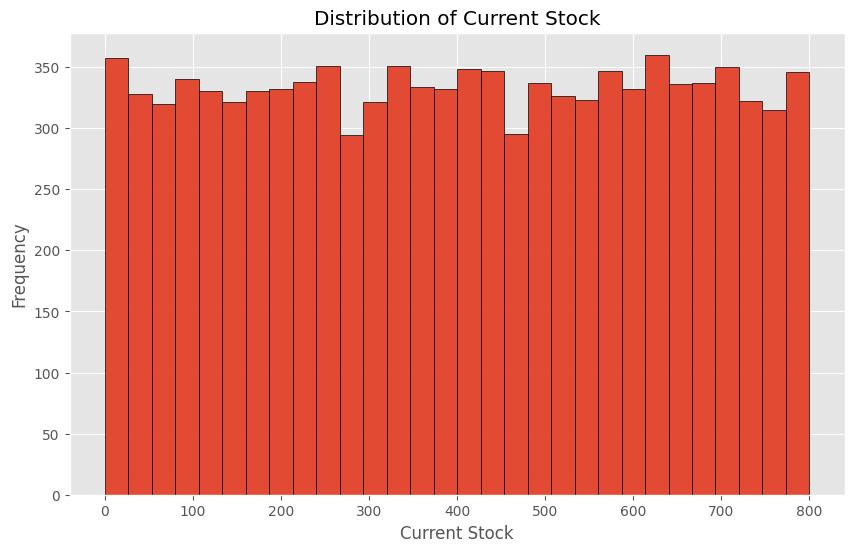

In [63]:
# ==========================================================
# STEP 15: CURRENT STOCK DISTRIBUTION
#
# Purpose:
#   Visualize how Current Stock is distributed across
#   all inventory records.
#
# Why?
#   This helps identify whether most products have
#   low, medium, or high stock levels.
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    inventory_clean["Current_Stock"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Current Stock")
plt.xlabel("Current Stock")
plt.ylabel("Frequency")

plt.show()

In [64]:
# ==========================================================
# STEP 16: INVENTORY OVERVIEW
#
# Purpose:
#   Calculate key inventory metrics that provide
#   a quick overview of the dataset.
# ==========================================================

print("Total Inventory Records :", len(inventory_clean))

print("Unique Products         :", inventory_clean["SKU"].nunique())

print("Average Current Stock   :", round(inventory_clean["Current_Stock"].mean(), 2))

print("Minimum Stock           :", inventory_clean["Current_Stock"].min())

print("Maximum Stock           :", inventory_clean["Current_Stock"].max())

Total Inventory Records : 10000
Unique Products         : 1000
Average Current Stock   : 400.42
Minimum Stock           : 0.0
Maximum Stock           : 800.0


### Key Findings

- Total inventory records analysed: 10,000

- 1,000 unique products are currently stored.

- Average inventory level is approximately 400 units.

- Some products currently have zero stock.

- Highest recorded inventory is 800 units.

In [65]:
# ==========================================================
# BUSINESS QUESTION 1
#
# Which warehouse currently stores
# the highest amount of inventory?
#
# Purpose:
# Compare inventory levels across warehouses
# to identify storage distribution.
# ==========================================================

warehouse_inventory = (
    inventory_clean
    .groupby("Warehouse")["Current_Stock"]
    .sum()
    .sort_values(ascending=False)
)

warehouse_inventory

Warehouse
KK           538954.0
Melaka       513006.0
Kuching      500814.0
Johor        500385.0
Shah Alam    498728.0
Penang       498671.0
Kuantan      479569.0
Ipoh         474058.0
Name: Current_Stock, dtype: float64

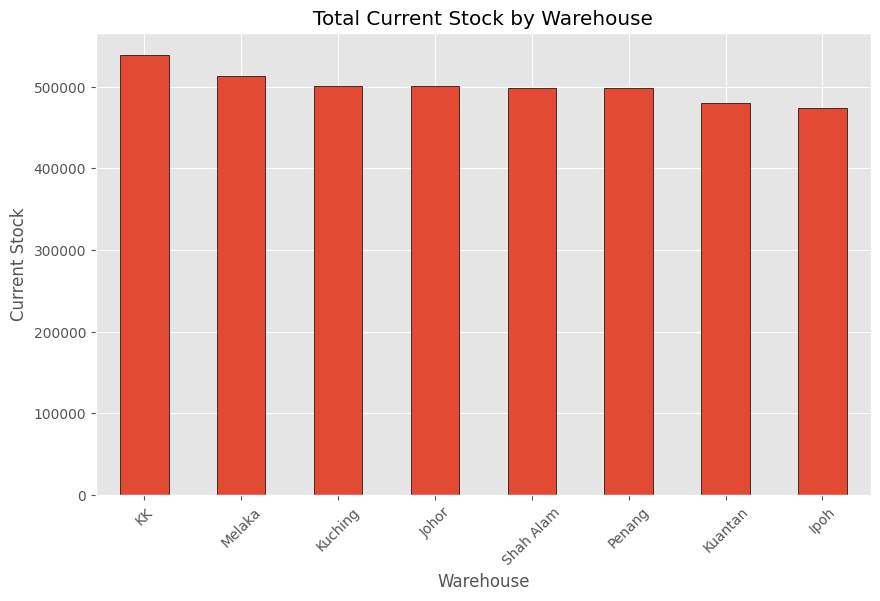

In [66]:
# ==========================================================
# VISUALIZATION
#
# Inventory by Warehouse
# ==========================================================

plt.figure(figsize=(10,6))

warehouse_inventory.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Total Current Stock by Warehouse")

plt.xlabel("Warehouse")

plt.ylabel("Current Stock")

plt.xticks(rotation=45)

plt.show()

## Business Insight

KK warehouse currently holds the highest inventory level (538,954 units), followed by Melaka (513,006 units) and Kuching (500,814 units).

However, a higher inventory level does not necessarily indicate better warehouse performance. The warehouse may be supporting higher customer demand, or it may be carrying excess inventory.

Further analysis should compare inventory levels with sales performance and inventory turnover to determine whether the inventory allocation is efficient.

In [73]:
# ==========================================================
# BUSINESS QUESTION 2
#
# Which products need to be reordered?
#
# Purpose:
#   Identify products where the current stock level
#   has fallen below the reorder threshold.
#
# Expected Output:
#   A list of products that require immediate replenishment.
# ==========================================================

reorder_products = inventory_clean[
    inventory_clean["Current_Stock"] < inventory_clean["Reorder_Level"]
]

print("Inventory records requiring reorder:", len(reorder_products))
print("Unique SKUs requiring reorder:", reorder_products["SKU"].nunique())
reorder_products

Inventory records requiring reorder: 768
Unique SKUs requiring reorder: 533


,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost
0,2025-04-01,KK,SKU0384,0.0,85,207,4,63.12
5,2024-12-05,Shah Alam,SKU0158,24.0,78,222,1,2.88
28,2025-10-08,Shah Alam,SKU0914,19.0,84,481,9,2.28
49,2024-03-28,Kuantan,SKU0653,19.0,56,385,9,2.28
72,2025-02-14,Kuching,SKU0624,38.0,69,533,9,4.56
...,...,...,...,...,...,...,...,...
9970,2024-12-29,Penang,SKU0395,59.0,98,295,8,7.08
9974,2025-08-26,Kuantan,SKU0260,51.0,57,421,6,6.12
9978,2024-11-23,Ipoh,SKU0223,63.0,75,435,2,7.56
9985,2024-11-16,Shah Alam,SKU0640,21.0,78,340,6,2.52


## Business Question

What products require immediate replenishment?

---

## Methodology

Products with Current Stock lower than the Reorder Level were identified using a conditional filter in Pandas.

---

## Findings

768 inventory records require reorder.

533 unique SKUs require reorder.

---

## Business Insight

More than half of the company's products are currently below the recommended reorder level, suggesting that inventory replenishment may not be keeping pace with demand. Several products have already reached zero stock, increasing the risk of stock-out events, lost sales, and reduced customer satisfaction if corrective actions are not taken promptly.

---

## Recommendation

- Prioritize replenishment for products with zero inventory.
- Review purchasing schedules for products consistently falling below the reorder level.
- Implement automated inventory alerts to notify the purchasing team before stock reaches critical levels.